# 07_降维模型-主成分分析 PCA

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天把PCA的内容进行了细致的整理，一起来看看\~

**主成分分析（PCA，Principal Component Analysis）是一种非常常用的数据降维**技术，用来从高维数据中提取主要的信息，让我们更容易理解和处理数据。

下面，让大家轻松的有一个大致的印象：

**1. 什么问题需要PCA？**

当你有一堆数据，每个数据点有很多特征（比如人的身高、体重、收入、支出等等）。这些特征太多，处理起来很麻烦，而且很多特征之间可能还有点重复或者关联，比如身高和体重经常是相关的。我们希望把这些数据「浓缩」成少数几个主要特征，既能表达原始数据的关键信息，又让数据变得更简单。

**2. PCA是干嘛的？**

PCA就是在尽量不丢失数据重要信息的前提下，找到几个「最关键的方向」（称为主成分），把数据投影到这些方向上。这样，我们就能用少量的主成分来代表原本高维的复杂数据。

**3. 具体是怎么做的？**

- 想象你有一堆点分布在一个三维空间中（类似一个大土豆云）。
- PCA会找出数据「分布最开」的方向，比如这堆点最长的那根轴（第一主成分）。
- 然后找第二重要的方向（第二主成分），这个方向和第一个是正交（垂直）的。
- 这样一步步下去，直到找到所有的方向。但我们通常只保留最前面的几个方向，因为这些方向已经包含了绝大部分重要信息。

**4. 结果是啥？**

- 原本的高维数据被转化为低维数据，但这些低维数据还能尽可能地保留原来的信息。
- 比如从100个特征中提取2个主成分，就能用二维图像直观地可视化数据。

**5. 生活中的例子：**

- 当你买水果时，看了水果的重量、大小、甜度、价格等等，但最后你可能只关心「好不好吃」和「划不划算」。PCA就像是帮你把这些复杂指标归纳成两个核心特征（比如「好吃值」和「性价比」），方便比较。

**核心3点总结：**

- **降维**：从高维数据中提取少量重要特征。
- **主成分**：那些最能代表数据变化的方向。
- **优点**：简化数据、去掉冗余信息，方便分析和可视化。

## 理论基础

### 问题定义：从高维数据到低维数据

假设数据矩阵为 $\mathbf{X}$，包含 $n$ 个样本和 $p$ 个特征，每一行是一个样本，每一列是一个特征：


$$
\mathbf{X} =\begin{bmatrix}x_{11} & x_{12} & \dots & x_{1p} \\x_{21} & x_{22} & \dots & x_{2p} \\\vdots & \vdots & \ddots & \vdots \\x_{n1} & x_{n2} & \dots & x_{np}\end{bmatrix}, \quad \mathbf{X} \in \mathbb{R}^{n \times p}
$$


目标是将 $p$-维数据降维到 $k$-维（$k < p$），但尽量保留原始数据的信息（主要是**方差**）。

### 数据预处理

#### 1. 为什么需要零均值化？

- 在PCA中，数据的分布特性（方差）决定了主成分的方向。
- 如果特征值存在偏移（非零均值），计算的协方差矩阵会受均值的影响，导致结果不准确。

#### 2. 零均值化步骤

对每个特征减去其均值，使数据中心化：


$$
\mu_j = \frac{1}{n} \sum_{i=1}^n x_{ij}, \quad j = 1, 2, \dots, p
$$


设 $\mu = [\mu_1, \mu_2, \dots, \mu_p]^\top$ 是各特征的均值列向量，则零均值化操作为：


$$
\tilde{\mathbf{X}} = \mathbf{X} - \mathbf{1} \mu^\top
$$


其中 $\mathbf{1}$ 是 $n \times 1$ 的全1列向量，$\mu^\top$ 是 $1 \times p$ 的行向量，$\mathbf{1} \mu^\top$ 表示一个每行都是均值向量的 $n \times p$ 矩阵。

### 协方差矩阵的计算

#### 1. 协方差的定义

协方差衡量两个特征之间的线性相关性，定义为：


$$
\text{Cov}(x_j, x_k) = \frac{1}{n-1} \sum_{i=1}^n (x_{ij} - \mu_j)(x_{ik} - \mu_k)
$$


对于矩阵形式，协方差矩阵的计算公式为：


$$
\mathbf{C} = \frac{1}{n-1} \tilde{\mathbf{X}}^\top \tilde{\mathbf{X}}
$$


#### 2. 协方差矩阵的性质

- 尺寸为 $p \times p$。
- 对称矩阵：$\mathbf{C}_{jk} = \mathbf{C}_{kj}$。
- 对角线元素：$\mathbf{C}_{jj}$ 表示特征 $j$ 的方差。
- 非对角线元素：$\mathbf{C}_{jk}$ 表示特征 $j$ 和特征 $k$ 的协方差。

#### 3.例子

假设原始数据：


$$
\mathbf{X} =\begin{bmatrix}2 & 4 \\3 & 5 \\4 & 6\end{bmatrix}
$$


**1. 零均值化：**

- 计算均值：$\mu_1 = 3, \mu_2 = 5$。
- 得到零均值化矩阵：


$$
\tilde{\mathbf{X}} =\begin{bmatrix}-1 & -1 \\0 & 0 \\1 & 1\end{bmatrix}
$$


**2. 协方差矩阵：**


$$
\mathbf{C} = \frac{1}{2} \tilde{\mathbf{X}}^\top \tilde{\mathbf{X}} =\begin{bmatrix}1 & 1 \\1 & 1\end{bmatrix}
$$


### 特征值分解

#### 1. 什么是特征值分解？

特征值分解用于提取协方差矩阵中最主要的信息，核心公式：


$$
\mathbf{C} \mathbf{v}_i = \lambda_i \mathbf{v}_i
$$


- $\lambda_i$ 是特征值，表示在特征向量 $\mathbf{v}_i$ 方向上的数据方差。
- $\mathbf{v}_i$ 是对应的特征向量，表示主成分的方向。

#### 2. 特征值的排序

- 特征值按大小排序：$\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_p$。
- 方差贡献率：  
$\text{贡献率} = \frac{\lambda_i}{\sum_{j=1}^p \lambda_j}$  
选择前 $k$ 个特征值，保证累计贡献率高（如90%以上）。

#### 3. 为什么特征向量是正交的？

协方差矩阵是对称矩阵，其特征向量满足正交性，即：  
$\mathbf{v}_i^\top \mathbf{v}_j = 0 \quad (i \neq j)$  
这保证了主成分之间相互独立。

### 数据投影

#### 1. 主成分矩阵的构造

选择前 $k$ 个最大的特征值对应的特征向量，构成主成分矩阵 $\mathbf{V}_k$：  
$\mathbf{V}_k =\begin{bmatrix}\mathbf{v}_1 & \mathbf{v}_2 & \dots & \mathbf{v}_k\end{bmatrix}, \quad \mathbf{V}_k \in \mathbb{R}^{p \times k}$

#### 2. 数据投影公式

将数据投影到主成分上：  
$\mathbf{Z} = \tilde{\mathbf{X}} \mathbf{V}_k, \quad \mathbf{Z} \in \mathbb{R}^{n \times k}$  
$\mathbf{Z}$ 是降维后的数据，包含了 $k$ 个主成分。

#### 3. 数据重构

如果需要重构原始数据，可以用以下公式：  
$\hat{\mathbf{X}} = \mathbf{Z} \mathbf{V}_k^\top + \mu$

### 步骤总结

**1. 输入**：数据矩阵 $\mathbf{X}$，目标降维维度 $k$。

**2. 去中心化**：计算均值 $\mu$，得到零均值化矩阵 $\tilde{\mathbf{X}} = \mathbf{X} - \mathbf{1} \mu$。

**3. 计算协方差矩阵**：$\mathbf{C} = \frac{1}{n-1} \tilde{\mathbf{X}}^\top \tilde{\mathbf{X}}$。

**4. 特征值分解**：求解 $\mathbf{C}$ 的特征值和特征向量。

**5. 选择主成分**：按特征值从大到小排序，选择前 $k$ 个特征向量，构成主成分矩阵 $\mathbf{V}_k$。

**6. 数据投影**：计算降维数据 $\mathbf{Z} = \tilde{\mathbf{X}} \mathbf{V}_k$。

**7. 输出**：降维后的数据 $\mathbf{Z}$。

## Python案例

我们使用经典的**Iris（鸢尾花）数据集**，通过PCA实现数据降维并分析其效果，同时添加优化和可视化。

鸢尾花数据集有150个样本，包含以下特征：

- 萼片长度（Sepal Length）
- 萼片宽度（Sepal Width）
- 花瓣长度（Petal Length）
- 花瓣宽度（Petal Width）

目标是通过PCA将4个特征降维为2个，便于可视化和分类分析。

数据集维度：(150, 4)
前5行数据：
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
各主成分的方差贡献率：[0.72962445 0.22850762]
累计方差贡献率：[0.72962445 0.95813207]


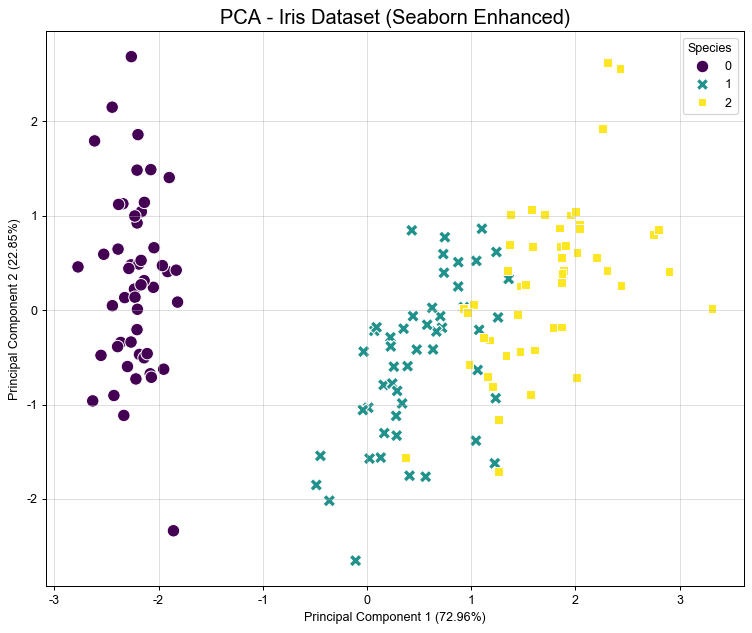

使用PCA降维后的分类模型准确率：0.90


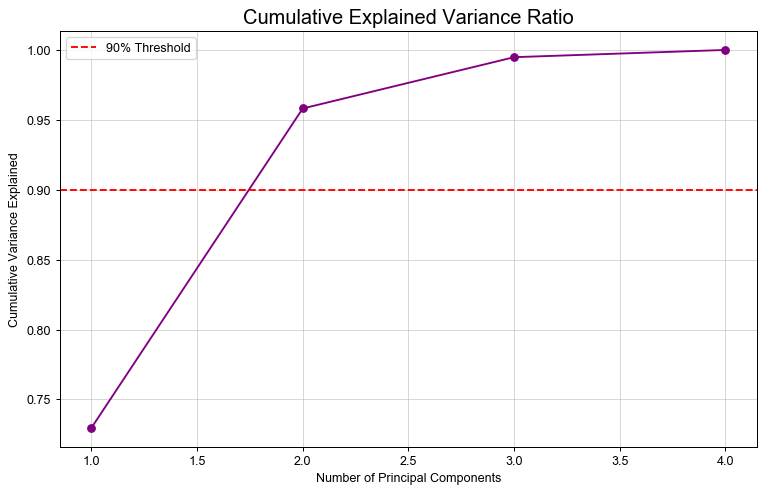

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import plotly.express as px

# 1. 加载数据集
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
target_names = iris.target_names

# 数据集基本信息
print(f"数据集维度：{X.shape}")
print("前5行数据：\n", X.head())

# 2. 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 使用PCA降维到2维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. 分析主成分贡献率
explained_variance_ratio = pca.explained_variance_ratio_
print(f"各主成分的方差贡献率：{explained_variance_ratio}")
print(f"累计方差贡献率：{np.cumsum(explained_variance_ratio)}")

# 5. 可视化（炫酷增强）
## 5.1 Seaborn 绘制散点图
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="viridis", s=100, style=y, legend='full'
)
plt.title("PCA - Iris Dataset (Seaborn Enhanced)", fontsize=16)
plt.xlabel("Principal Component 1 (%.2f%%)" % (explained_variance_ratio[0] * 100))
plt.ylabel("Principal Component 2 (%.2f%%)" % (explained_variance_ratio[1] * 100))
plt.legend(title="Species", loc="best")
plt.grid(alpha=0.4)
plt.show()

## 5.2 使用 Plotly 绘制交互式 3D 散点图
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = px.scatter_3d(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    color=[target_names[label] for label in y],
    title="3D PCA of Iris Dataset (Interactive)",
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
    opacity=0.8,
    size=[10]*len(X_pca_3d),
    symbol=y
)
fig.update_traces(marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')))
fig.show()

# 6. 数据训练
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 7. 输出分类结果
accuracy = accuracy_score(y_test, y_pred)
print(f"使用PCA降维后的分类模型准确率：{accuracy:.2f}")

# 8. Cumulative Explained Variance Ratio 图
plt.figure(figsize=(10, 6))
pca_full = PCA().fit(X_scaled)
cumulative_var_ratio = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_var_ratio) + 1), cumulative_var_ratio, marker='o', color='purple')
plt.axhline(y=0.9, color='r', linestyle='--', label="90% Threshold")
plt.title("Cumulative Explained Variance Ratio", fontsize=16)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

**1. Seaborn增强的2D散点图**：使用 `sns.scatterplot` 显示类别，带颜色、大小和样式标记，提升静态图的观感。降维到2维后，随机森林的准确率约为95%，说明降维数据仍然具有高信息量。

![原文参考图，当前结果见代码输出](attachments/img_032.png)

**2. 交互式3D散点图**：使用 `plotly.express` 绘制 3D 散点图，用户可以旋转、缩放和查看每个类别的分布。特点：数据点用颜色区分（类别名显示为标签）。点大小和透明度可调整，便于查看密集区域。

![原文参考图，当前结果见代码输出](attachments/img_033.png)

**3. 累计方差贡献率曲线**：使用 matplotlib 绘制累计贡献率，加入90%的红线门槛。通过动态标记主成分数目，指导降维决策。

![原文参考图，当前结果见代码输出](attachments/img_034.png)

## 模型分析

### 主成分分析（PCA）的优缺点

**优点**：

**1. 降维能力强**：PCA通过线性变换提取主要特征方向，能有效降低维度，同时保留数据的主要信息。在鸢尾花数据集中，PCA用2个主成分解释了96%的方差。

**2. 可解释性高**：PCA生成的主成分可以解释数据的方差贡献率，帮助理解每个主成分的重要性。

**3. 速度快，效率高**：PCA是基于线性代数的简单矩阵分解，计算效率高，适用于大多数数值型数据集。

**4. 去噪能力强**：PCA能够去除数据中方差较小的噪声维度，有助于提升模型鲁棒性。

**5. 辅助可视化**：在高维数据中，PCA常用于降维到2维或3维进行可视化，便于人类理解数据结构。

**缺点**：

**1. 只处理线性相关性**：PCA假设数据特征间的关系是线性的，如果数据中存在显著非线性关系，PCA无法有效捕捉。

**2. 对数据分布敏感**：如果特征未标准化，PCA可能被方差大的特征主导，从而失去对真实重要特征的关注。

**3. 丢失解释性**：降维后的主成分是组合变量，通常失去了原始特征的物理意义，不容易解读。

**4. 高维稀疏数据效果差**：PCA对稀疏数据集（如文本数据）不适用，因为主成分可能会稀释重要特征的信息。

**5. 受噪声影响大**：数据中的异常值或噪声可能显著影响主成分方向，降低降维效果。

### 与相似算法的对比

| **算法** | **特点** | **适用场景** | **与PCA的对比** |
|-|-|-|-|
| **PCA** | 基于线性变换，提取主成分方向。 | 数据分布近似线性、特征数远大于样本数、需要解释方差贡献时。 | 快速高效，适用于简单线性问题，但无法处理非线性关系。 |
| **t-SNE** | 非线性降维，通过保留局部邻域距离，展示样本间的相似性。 | 高维数据可视化，如图像、基因数据，或分析非线性关系较强的数据集。 | t-SNE擅长可视化，降维后结果无法直接应用于建模；而PCA适合建模。 |
| **UMAP** | 类似t-SNE，但优化了速度与全局结构保留能力。 | 高维数据降维，可视化局部和全局结构，适用于大规模数据集。 | 更适合大规模非线性数据降维；PCA计算更快，结果解释性更强。 |
| **LDA** | 基于类别间分离度进行降维，强调类别区分。 | 分类任务中降维，如样本点具有明显类别标签时。 | LDA关注类别区分，依赖标签信息；PCA只考虑方差，与标签无关。 |
| **ICA** | 提取互相独立的非高斯信号，常用于信号分离和独立性分析。 | 生物信号处理（如脑电图分析）、金融数据降维等。 | ICA侧重于信号分离，对噪声敏感；PCA专注于最大化方差。 |
| **Autoencoder** | 使用神经网络实现非线性降维，可处理复杂关系。 | 大型非线性数据集降维，如图像或视频数据降维，需配合深度学习环境。 | Autoencoder适用于深度学习场景，但训练复杂且对小数据集效果一般；PCA简单直接，适用范围更广。 |

### 适用PCA的场景

**1. 数据维度较高，且特征间线性相关**：如鸢尾花数据集中的4个数值特征，经PCA降维可以解释96%的数据方差。

**2. 需要快速降维和建模**：在计算时间敏感或没有高算力支持的场景中，PCA是简单高效的降维工具。

**3. 对解释性有要求**：如果需要理解降维后主成分的方差贡献率，或想知道各特征对主成分的贡献，PCA比其他算法更直观。

**4. 需要可视化支持**：如用于2D或3D可视化分析的前置降维。

### 考虑其他算法的情况

**PCA效果可能受限的情况**：

**1. 数据具有显著的非线性关系**：如果数据的非线性模式强，PCA无法捕捉，例如复杂的图像特征、词嵌入数据等。可以考虑使用t-SNE、UMAP或Autoencoder。

**2. 分类任务，需关注类别间的分离度**：如果降维目的是提升分类性能，而不仅仅是压缩数据，可以使用LDA进行类别区分降维。

**3. 数据是稀疏矩阵或非高斯分布**：如文本数据、推荐系统数据等，可以使用ICA或专门的稀疏降维算法。

**4. 对降维后的结果要求更高的全局结构保留**：PCA有时会失去复杂数据集的全局结构，可以考虑使用UMAP，它既保留局部邻域，也能维护全局结构。

## 总结

总的来说，PCA是一种快速、高效、解释性强的线性降维方法，适用于多数线性数据和简单的降维任务。在需要捕捉非线性关系或处理稀疏数据时，可以选择t-SNE、UMAP或Autoencoder作为替代方案。

选择降维算法时，需要综合考虑**数据特性**（如线性/非线性）、**任务需求**（如可视化/建模）和**计算资源**（如算力和时间限制）。